# CA Experiment 5: Logits-Level QPM→SLM Steering via Residual Stream Injection

**Runtime:** Colab Pro **A100 GPU** + Anthropic API (Claude Sonnet 4.5 judge).

This notebook implements direct residual-stream activation steering to replace the JSON personality-state channel, testing whether bypassing JSON-mediated personality transmission can recover the QPM's downstream behavioural advantage.

| Condition | Interface | Personality channel |
|---|---|---|
| **A** | JSON marginals only (Exp 4/3 control) | JSON text |
| **B** | Diagonal activation steering, no JSON personality | Residual stream injection |
| **C** | JSON marginals + diagonal steering (dual channel) | Both |
| **D** | Diagonal + coherence steering, no JSON personality | Residual stream injection (+ purity) |

**Phase 0** (Cells 4a–4f): Extract steering vectors and lock `steering_config.json` before any experimental condition runs.

**H_logits (primary):** Condition B > Condition A, p < 0.05, d_z ≥ 0.2
**H_coherence (secondary):** Condition D > Condition B, p < 0.05, d_z ≥ 0.1

Estimated cost: ~$16.57 in Sonnet 4.5 judge calls + Colab Pro compute (~3 weeks total).

In [1]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/CA_Experiment_5'
EXP4_DIR    = '/content/drive/MyDrive/CA_Experiment_4'
EXP2_DIR    = '/content/drive/MyDrive/CA_Experiment_2'
EXP1_DIR    = '/content/drive/MyDrive/CA_Experiment_1'

assert os.path.exists(PROJECT_DIR), f'Upload CA_Experiment_5 to Drive first! Not found at {PROJECT_DIR}'
assert os.path.exists(EXP2_DIR), f'CA_Experiment_2 must be on Drive (LoRA-10K adapter + SCI assets). Not found at {EXP2_DIR}'
assert os.path.exists(EXP1_DIR), f'CA_Experiment_1 must be on Drive (30-script eval bank). Not found at {EXP1_DIR}'

ANTHROPIC_API_KEY = ''
for secret_name in ('ANTHROPIC_API_KEY', 'CHA_EXPERIMENT_SONNET_KEY'):
    try:
        ANTHROPIC_API_KEY = userdata.get(secret_name)
        if ANTHROPIC_API_KEY:
            print(f'API key loaded from Colab Secrets ({secret_name})')
            break
    except Exception:
        pass

if not ANTHROPIC_API_KEY:
    for env_path in [os.path.join(PROJECT_DIR, '.env'), os.path.join(EXP1_DIR, '.env')]:
        if os.path.exists(env_path):
            with open(env_path) as f:
                for line in f:
                    for key_prefix in ('ANTHROPIC_API_KEY=', 'CHA_EXPERIMENT_SONNET_KEY='):
                        if line.startswith(key_prefix):
                            ANTHROPIC_API_KEY = line.strip().split('=', 1)[1]
                            print(f'API key loaded from {env_path}')
                            break
                    if ANTHROPIC_API_KEY:
                        break
            if ANTHROPIC_API_KEY:
                break

assert ANTHROPIC_API_KEY, 'No API key found. Set ANTHROPIC_API_KEY via Colab Secrets.'
os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY
os.environ['CHA_EXPERIMENT_SONNET_KEY'] = ANTHROPIC_API_KEY

print(f'Project dir : {PROJECT_DIR}')
print(f'Exp 2 dir   : {EXP2_DIR}')
print(f'Exp 1 dir   : {EXP1_DIR}')
print(f'API key     : ...{ANTHROPIC_API_KEY[-8:]}')

Mounted at /content/drive
API key loaded from /content/drive/MyDrive/CA_Experiment_5/.env
Project dir : /content/drive/MyDrive/CA_Experiment_5
Exp 2 dir   : /content/drive/MyDrive/CA_Experiment_2
Exp 1 dir   : /content/drive/MyDrive/CA_Experiment_1
API key     : ...9tYw8wAA


## Cell 2: Install Python Dependencies

In [2]:
!pip install -q qiskit qiskit-aer pylatexenc vaderSentiment anthropic python-dotenv

import os, sys
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

import ca_assets as A
from qpm import QPM, QUBIT_LABELS, N_TRAIT_QUBITS
from steering_vectors import TRAIT_KEYS, CANDIDATE_LAYERS, D_MODEL

print(f'Trait qubits    : {N_TRAIT_QUBITS}')
print(f'Trait keys      : {TRAIT_KEYS}')
print(f'Conditions      : {A.CONDITIONS}')
print(f'Condition descs : {A.CONDITION_DESCRIPTIONS}')
print(f'Steering layers : {CANDIDATE_LAYERS}  (candidate layers for Phase 0)')
print(f'd_model         : {D_MODEL}  (Qwen2.5-7B hidden size)')

import anthropic
client = anthropic.Anthropic()
resp = client.messages.create(model='claude-sonnet-4-5', max_tokens=10,
                               messages=[{'role': 'user', 'content': 'Say "ok".'}])
print(f'API smoke test  : {resp.content[0].text}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 132.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 144.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.8/929.8 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.9 MB/s eta 0:00:00
Trait qubits    : 11
Trait keys      : ['O_exp', 'O_int', 'O_val', 'C_ind', 'C_ord', 'E_ent', 'E_ass', 'A_com', 'A_pol', 'N_vol', 'N_wth']
Conditions      : ('A', 'B', 'C', 'D')
Condition descs : {'A': 'JSON marginals only (Exp 4/3 control replication)', 'B': 'Diagonal activation steering — no JSON personality', 'C': 'JSON marginals + diagonal activation steering (dual channel)', 'D': 'Diagonal + co

## Cell 3: Verify GPU & LoRA-10K Adapter

Experiment 5 requires:
1. **A100 or L4 GPU** for Qwen2.5-7B-Instruct (4-bit NF4) inference and Phase 0 forward passes.
2. The Experiment 2 **LoRA-10K** adapter at `CA_Experiment_2/adapters/lora_10k/`.
3. Phase 0 forward passes (1,200 inputs × 4 candidate layers) — GPU required.

In [3]:
!pip install -q -U transformers peft "bitsandbytes>=0.46.1" accelerate

import torch
from pathlib import Path

print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    gpu_name  = torch.cuda.get_device_name(0)
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU            : {gpu_name}')
    print(f'VRAM           : {total_vram:.1f} GB')
    if total_vram < 20:
        raise RuntimeError(f'Experiment 5 requires L4 (22.5 GB) or A100 (40/80 GB). Current GPU: {total_vram:.1f} GB.')
else:
    raise RuntimeError('No GPU detected. Change runtime type to L4 / A100 GPU.')

import bitsandbytes as bnb
print(f'bitsandbytes   : {bnb.__version__}')
assert tuple(int(p) for p in bnb.__version__.split('.')[:2]) >= (0, 46), (
    f'bitsandbytes {bnb.__version__} too old (need >= 0.46.1). Restart and re-run this cell.')

adapter_path = Path(EXP2_DIR) / 'adapters' / 'lora_10k'
assert adapter_path.exists(), (
    f'LoRA-10K adapter not found at {adapter_path}. '
    'Ensure CA_Experiment_2/adapters/lora_10k/ is on your Drive.')
print(f'LoRA-10K       : {adapter_path}  ({len(sorted(adapter_path.glob("adapter_*")))} files)')
print('Experiment 5 environment: READY')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 140.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 33.9 MB/s eta 0:00:00
CUDA available : True
GPU            : NVIDIA A100-SXM4-80GB
VRAM           : 85.1 GB
bitsandbytes   : 0.49.2
LoRA-10K       : /content/drive/MyDrive/CA_Experiment_2/adapters/lora_10k  (2 files)
Experiment 5 environment: READY


## Cell 4a: Phase 0 — Sample Contrastive Corpus

Samples N=100 conversation turns from the 30 experimental scripts (turns 10–30 only).
Then builds all 2,400 contrastive forward-pass inputs:
- 11 trait vectors × 100 turns × 2 (high/low) = 2,200 inputs
- 1 coherence vector × 100 turns × 2 = 200 inputs

These inputs are used in Cell 4b to extract residual-stream activations at 4 candidate layers.
Using experimental-script turns here is safe: the steering vectors are *difference* vectors
averaged across many contexts, not script-specific (plan §4.2 Step 1).

In [ ]:
import os, sys
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

from pathlib import Path
import ca_assets as A
from steering_vectors import sample_experimental_turns, build_contrastive_inputs, TRAIT_KEYS

SCRIPT_IDS = list(range(1, 23)) + list(range(81, 89))  # 22 naturalistic + 8 adversarial
EXP1_SCRIPTS_DIR = Path(EXP1_DIR) / 'scripts'
PROFILE = A.PROFILES['psychotherapy']

# Step 1: Sample 100 turns from scripts
sampled_turns = sample_experimental_turns(
    script_ids=SCRIPT_IDS,
    scripts_dir=EXP1_SCRIPTS_DIR,
    n=100,
    turn_range=(10, 30),
    seed=42,
)
print(f'Sampled {len(sampled_turns)} turns from {len(set(t["script_id"] for t in sampled_turns))} scripts')
print('Example turns:')
for t in sampled_turns[:3]:
    print(f'  script={t["script_id"]:03d}  turn={t["turn_num"]:02d}  msg={t["user_message"][:60]}...')

Sampled 100 turns from 29 scripts
Example turns:
  script=021  turn=19  msg=I tried to talk about this with my roommate but they just do...
  script=004  turn=22  msg=Can I be honest? Part of me doesn't want this to get better ...
  script=001  turn=26  msg=Okay, I need to say something I've been avoiding. I think de...


In [ ]:
# Load tokenizer (no model needed yet — just for tokenization)
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct', trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Steps 2+3: Build contrastive inputs
contrastive_inputs = build_contrastive_inputs(
    sampled_turns=sampled_turns,
    profile=PROFILE,
    tokenizer=tokenizer,
    import_ca=A,
)
n_turns = contrastive_inputs['n_turns']
print(f'\nContrastive corpus ready:')
print(f'  Turns: {n_turns}')
print(f'  Trait inputs: {len(TRAIT_KEYS)} traits × {n_turns} turns × 2 = {len(TRAIT_KEYS)*n_turns*2}')
print(f'  Coherence inputs: {n_turns} turns × 2 = {n_turns*2}')
print(f'  Total forward passes: {(len(TRAIT_KEYS)*2 + 2) * n_turns}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

  Building contrastive inputs for 100 turns × (11 traits + coherence) × 2 = 2400 forward-pass inputs...
    10/100 turns prepared
    20/100 turns prepared
    30/100 turns prepared
    40/100 turns prepared
    50/100 turns prepared
    60/100 turns prepared
    70/100 turns prepared
    80/100 turns prepared
    90/100 turns prepared
    100/100 turns prepared

Contrastive corpus ready:
  Turns: 100
  Trait inputs: 11 traits × 100 turns × 2 = 2200
  Coherence inputs: 100 turns × 2 = 200
  Total forward passes: 2400


## Cell 4b: Phase 0 — Forward Pass Extraction (All 4 Candidate Layers)

Runs all 2,400 contrastive forward passes through Qwen2.5-7B + LoRA-10K and captures
the residual-stream state (last token) at each of the 4 candidate injection layers:
L ∈ {10, 14, 18, 22} (the "middle third" of the 28-layer stack, plan Appendix A.1).

Activations are saved to `phase0_activations/activations.npz` for resumability.
Then computes and normalises the 12 steering vectors (11 trait + 1 coherence) per layer.

**Expected duration: ~40–60 min on A100 (2,400 forward passes × 4 layer captures).**

In [ ]:
import os, sys
os.chdir(PROJECT_DIR)

import torch
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from steering_vectors import (
    extract_all_activations, compute_steering_vectors,
    CANDIDATE_LAYERS, ACTIVATIONS_CACHE_DIR
)

# Load model + LoRA adapter for forward passes
bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True,
)
model_name = 'Qwen/Qwen2.5-7B-Instruct'
adapter_path = Path(EXP2_DIR) / 'adapters' / 'lora_10k'

base_model = AutoModelForCausalLM.from_pretrained(
    model_name, quantization_config=bnb, device_map='auto', trust_remote_code=True,
)
model = PeftModel.from_pretrained(base_model, str(adapter_path))
model.eval()
print(f'Model loaded: {model_name} + lora_10k')

# Step 4: Extract activations (cached after first run)
cache_dir = Path(PROJECT_DIR) / 'phase0_activations'
activations = extract_all_activations(
    model=model,
    contrastive_inputs=contrastive_inputs,
    candidate_layers=CANDIDATE_LAYERS,
    cache_dir=cache_dir,
)

# Step 5: Compute + normalize steering vectors
steering_vectors_by_layer = compute_steering_vectors(activations, CANDIDATE_LAYERS)

# Summary: show vector norms (should all be 1.0 after normalisation)
import numpy as np
for L in CANDIDATE_LAYERS:
    norms = {k: float(np.linalg.norm(steering_vectors_by_layer[L][k]))
             for k in list(steering_vectors_by_layer[L].keys())[:3]}
    print(f'  Layer {L} sample norms: {norms}  (all should be ~1.0)')
print('\nPhase 0 Steps 1–5 complete: steering vectors computed for all candidate layers.')

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Model loaded: Qwen/Qwen2.5-7B-Instruct + lora_10k
  Running 2400 forward passes across 4 candidate layers (100 turns × 11 traits × 2 + 100 × 2 coherence)...
  [ 101/2400]  O_exp low                     elapsed=15s  6.73/s  ETA=341s
  [ 208/2400]  O_int high                    elapsed=30s  6.93/s  ETA=316s
  [ 314/2400]  O_int low                     elapsed=45s  6.98/s  ETA=299s
  [ 421/2400]  O_val high                    elapsed=60s  7.02/s  ETA=282s
  [ 527/2400]  O_val low                     elapsed=75s  7.03/s  ETA=267s
  [ 633/2400]  C_ind high                    elapsed=90s  7.03/s  ETA=251s
  [ 739/2400]  C_ind low                     elapsed=105s  7.04/s  ETA=236s
  [ 845/2400]  C_ord high                    elapsed=120s  7.04/s  ETA=221s
  [ 951/2400]  C_ord low                     elapsed=135s  7.04/s  ETA=206s
  [1058/2400]  E_ent high                    elapsed=150s  7.05/s  ETA=190s
  [1164/2400]  E_ent low                     elapsed=165s  7.05/s  ETA=175s
  [1270/2400]

## Cell 4c: Phase 0 — Generate Calibration Scripts

Generates 2 calibration scripts via Claude Sonnet 4.5 and saves them to
`calibration_scripts/script_cal_001.json` and `script_cal_002.json`.

Layer calibration (Cell 4c-run) uses held-out scripts — not from the 30 experimental
scripts — to avoid peeking at Condition B performance before the formal run
(plan §4.2 Step 6). **Review the generated scripts before proceeding.**


In [ ]:
import os, sys, json
os.chdir(PROJECT_DIR)

from pathlib import Path
from steering_vectors import generate_calibration_scripts

cal_dir = Path(PROJECT_DIR) / 'calibration_scripts'
cal_dir.mkdir(exist_ok=True)

print('Generating 2 calibration scripts via Claude Sonnet 4.5...')
calibration_scripts = generate_calibration_scripts(n=2, output_dir=cal_dir, seed=2025)

print(f'\nSaved to {cal_dir}')
for i, s in enumerate(calibration_scripts, 1):
    print(f'  Script {i}: {s.get("scenario", "N/A")[:70]}')
    print(f'    Turns  : {len(s.get("turns", []))}')
    probe_slots = sum(1 for t in s.get('turns', []) if t.get('user_message') == 'PROBE_SLOT')
    print(f'    PROBE_SLOT turns: {probe_slots}  (expected 8)')

Generating 2 calibration scripts via Claude Sonnet 4.5...
  Generated calibration script 1: A client seeks help managing workplace anxiety and learns br
  Generated calibration script 2: A client is working through grief after losing their mother 

Saved to /content/drive/MyDrive/CA_Experiment_5/calibration_scripts
  Script 1: A client seeks help managing workplace anxiety and learns breathing te
    Turns  : 40
    PROBE_SLOT turns: 8  (expected 8)
  Script 2: A client is working through grief after losing their mother six months
    Turns  : 40
    PROBE_SLOT turns: 8  (expected 8)


## Cell 4c-inspect: Review Calibration Scripts

Loads the generated scripts and prints each turn so you can spot-check:
- Naturalistic psychotherapy scenario (not adversarial, not generic)
- 40 turns numbered 1–40
- `user_message = 'PROBE_SLOT'` on turns 5, 10, 15, 20, 25, 30, 35, 40
- Other turns have varied, plausible user messages


In [ ]:
import json
from pathlib import Path

cal_dir = Path(PROJECT_DIR) / 'calibration_scripts'
for fname in sorted(cal_dir.glob('script_cal_*.json')):
    s = json.loads(fname.read_text())
    print(f'=== {fname.name}: {s.get("scenario", "")} ===')
    for t in s.get('turns', []):
        msg = t.get('user_message', '')
        flag = '  ◆ PROBE' if msg == 'PROBE_SLOT' else ''
        print(f'  T{t["turn"]:02d}: {msg[:80]}{flag}')
    print()

=== script_cal_001.json: A client seeks help managing workplace anxiety and learns breathing techniques to cope with stress. ===
  T01: Hi Aria, I've been feeling really overwhelmed at work lately. My anxiety has bee
  T02: It's mainly during meetings and presentations. My heart races and I feel like I 
  T03: Yeah, it happens almost every time now. I used to be fine with public speaking, 
  T04: I've tried just pushing through it, but that doesn't seem to help. Sometimes I h
  T05: PROBE_SLOT  ◆ PROBE
  T06: That makes sense. I never really thought about my breathing patterns during thos
  T07: I'm willing to try anything at this point. What kind of breathing exercises do y
  T08: Okay, I'm ready to try it now. Should I close my eyes or keep them open?
  T09: That actually feels calming already. How long should I practice this each day?
  T10: PROBE_SLOT  ◆ PROBE
  T11: I can definitely do that. Do you think this will help me during the actual stres
  T12: That's really helpful to kno

### Checkpoint

Review the scripts above. Proceed to Cell 4c-run only if both scripts:
- Have exactly 40 turns
- Have `PROBE_SLOT` on turns 5, 10, 15, 20, 25, 30, 35, 40
- Read as naturalistic, plausible psychotherapy sessions

If either script fails review: delete `calibration_scripts/` and re-run Cell 4c with a
different seed (change `seed=2025` to `seed=2026`, etc.).


## Cell 4c-run: Phase 0 — Layer Calibration (Select L*)

Runs Condition B diagonal steering on the 2 calibration scripts at each candidate
layer L ∈ {10, 14, 18, 22}, judges 32 probe responses per layer, and selects
L* = argmax PersonaScore (tie-break: prefer lower layer).

Expected: ~256 judge calls × 4 layers ≈ $1.02.


In [ ]:
# Run layer calibration
# (Assumes investigator has reviewed calibration_scripts above)
import anthropic
from steering_vectors import calibrate_layer

judge_client = anthropic.Anthropic()

L_STAR = calibrate_layer(
    model=model,
    tokenizer=tokenizer,
    steering_vectors_by_layer=steering_vectors_by_layer,
    calibration_scripts=calibration_scripts,
    judge_client=judge_client,
    profile=A.PROFILES['psychotherapy'],
    import_ca=A,
    alpha_initial=2.0,
    candidate_layers=CANDIDATE_LAYERS,
)

print(f'\nSelected L* = {L_STAR}')
print(f'This is the injection layer for all steering conditions (B, C, D).')

# Use the selected layer's vectors going forward
steering_vectors = steering_vectors_by_layer[L_STAR]
print(f'Steering vectors at L*={L_STAR}: {list(steering_vectors.keys())}')


  Layer 10: running 2 calibration scripts...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    L=10  turn=05  scores=[5.0, 1.0, 4.0, 5.0]  running_mean=3.750  n=4
    L=10  turn=10  scores=[5.0, 4.0, 5.0, 5.0]  running_mean=4.250  n=8
    L=10  turn=15  scores=[5.0, 5.0, 5.0, 5.0]  running_mean=4.500  n=12
    L=10  turn=20  scores=[4.0, 4.0, 4.0, 5.0]  running_mean=4.438  n=16
    L=10  turn=25  scores=[4.0, 4.0, 5.0, 5.0]  running_mean=4.450  n=20
    L=10  turn=30  scores=[5.0, 1.0, 2.0, 5.0]  running_mean=4.250  n=24
    L=10  turn=35  scores=[5.0, 2.0, 5.0, 5.0]  running_mean=4.250  n=28
    L=10  turn=40  scores=[5.0, 2.0, 5.0, 5.0]  running_mean=4.250  n=32
    L=10  turn=05  scores=[5.0, 4.0, 5.0, 5.0]  running_mean=4.306  n=36
    L=10  turn=10  scores=[5.0, 2.0, 5.0, 5.0]  running_mean=4.300  n=40
    L=10  turn=15  scores=[5.0, 1.0, 5.0, 5.0]  running_mean=4.273  n=44
    L=10  turn=20  scores=[5.0, 4.0, 5.0, 5.0]  running_mean=4.312  n=48
    L=10  turn=25  scores=[5.0, 4.0, 4.0, 5.0]  running_mean=4.327  n=52
    L=10  turn=30  scores=[5.0, 5.0, 4.0, 5.0]  runni

## Cell 4d: Phase 0 — Scale Factor Calibration (α and α_coh)

Sweeps α ∈ {0.5, 1.0, 2.0, 5.0, 10.0} on 50 probe turns from the experimental scripts
and selects α = 0.75 × α_max where α_max is the largest α with grammaticality ≥ 95%.

Calibrates α_coh separately using only the coherence component (diagonal vectors zeroed).

If α_max < 2.0 the steering vectors may be misaligned — see plan §8.4.

In [ ]:
import os, sys
os.chdir(PROJECT_DIR)

from steering_vectors import calibrate_alpha, sample_experimental_turns
from pathlib import Path

EXP1_SCRIPTS_DIR = Path(EXP1_DIR) / 'scripts'
PROFILE = A.PROFILES['psychotherapy']
SCRIPT_IDS = list(range(1, 23)) + list(range(81, 89))

# Use same 50 sampled turns (from Cell 4a) for alpha calibration
# (safe: only grammaticality checked, not PersonaScore — plan §5.2)
probe_turns = sampled_turns  # from Cell 4a

print('=== Alpha calibration (diagonal component) ===')
alpha = calibrate_alpha(
    model=model, tokenizer=tokenizer,
    steering_vectors=steering_vectors,
    L_star=L_STAR,
    probe_turns=probe_turns,
    profile=PROFILE,
    import_ca=A,
    component='diagonal',
)

print(f'\n=== Alpha_coh calibration (coherence component) ===')
alpha_coh = calibrate_alpha(
    model=model, tokenizer=tokenizer,
    steering_vectors=steering_vectors,
    L_star=L_STAR,
    probe_turns=probe_turns,
    profile=PROFILE,
    import_ca=A,
    component='coherence',
)

print(f'\nCalibrated parameters:')
print(f'  L*       = {L_STAR}')
print(f'  alpha    = {alpha}')
print(f'  alpha_coh= {alpha_coh}')

=== Alpha calibration (diagonal component) ===
  Alpha calibration (diagonal component) over 100 turns × 5 candidates...
    [  1/500]  alpha=0.5  turn=2/100  elapsed=15s  ETA=7485s
    [  3/500]  alpha=0.5  turn=4/100  elapsed=30s  ETA=4970s
    [  5/500]  alpha=0.5  turn=6/100  elapsed=45s  ETA=4479s
    [  5/500]  alpha=0.5  turn=6/100  elapsed=60s  ETA=5964s
    [  7/500]  alpha=0.5  turn=8/100  elapsed=75s  ETA=5299s
    [  9/500]  alpha=0.5  turn=10/100  elapsed=90s  ETA=4923s
    [ 10/500]  alpha=0.5  turn=11/100  elapsed=105s  ETA=5157s
    [ 12/500]  alpha=0.5  turn=13/100  elapsed=120s  ETA=4890s
    [ 14/500]  alpha=0.5  turn=15/100  elapsed=135s  ETA=4695s
    [ 16/500]  alpha=0.5  turn=17/100  elapsed=150s  ETA=4545s
    [ 18/500]  alpha=0.5  turn=19/100  elapsed=165s  ETA=4425s
    [ 19/500]  alpha=0.5  turn=20/100  elapsed=180s  ETA=4563s
    [ 21/500]  alpha=0.5  turn=22/100  elapsed=195s  ETA=4454s
    [ 23/500]  alpha=0.5  turn=24/100  elapsed=210s  ETA=4360s
    [ 25

## Cell 4e: Phase 0 — Qualitative Validation

Generates 5 high-profile + 5 low-profile samples (all traits at 0.95 vs 0.05) and asks
Claude Sonnet 4.5 to confirm the steering vectors create distinguishable outputs.

**Why full-profile contrast instead of per-trait:** the composite vector mixes all 11
trait vectors. Varying one trait while others remain at baseline creates a small
perturbation (~1/11 of the composite) that is too subtle for a judge to call reliably.
Full-profile contrast maximises the signal and correctly reflects how the vectors will
be used in the experiment (all traits steered simultaneously).

Pass criterion: judge confirms HIGH-profile and LOW-profile responses are meaningfully
different in personality or communication style (plan §4.2 Step 8).

In [ ]:
import os, sys, json, random, re, numpy as np
os.chdir(PROJECT_DIR)

from steering_vectors import _build_composite_vector_np, _generate_steered
import ca_assets as A
import anthropic

sv = steering_vectors_by_layer[L_STAR]
TRAIT_KEYS_sv = [k for k in sv if k != 'coherence']
rng = random.Random(99)

print('Running qualitative validation (full-profile contrast)...')
print('Generates 5 high-profile + 5 low-profile samples, asks Claude Sonnet 4.5 to judge.\n')

marginals_all_high = {k: 0.95 for k in TRAIT_KEYS_sv}
marginals_all_low  = {k: 0.05 for k in TRAIT_KEYS_sv}

intent_h = A.qpm_to_structured_intent_b(marginals_all_high, [0.5]*5)
sp_h = A.build_condition_system_prompt("B", intent_h)

high_outputs, low_outputs = [], []
sample_turns = rng.sample(sampled_turns, min(5, len(sampled_turns)))

for i, turn in enumerate(sample_turns):
    v_high = _build_composite_vector_np(marginals_all_high, sv, alpha)
    v_low  = _build_composite_vector_np(marginals_all_low,  sv, alpha)
    out_h = _generate_steered(model, tokenizer, sp_h, [], turn["user_message"], v_high, L_STAR)
    out_l = _generate_steered(model, tokenizer, sp_h, [], turn["user_message"], v_low,  L_STAR)
    high_outputs.append(out_h)
    low_outputs.append(out_l)
    print(f'  Generated sample {i+1}/5', flush=True)

client = anthropic.Anthropic()
judge_prompt = (
    "HIGH personality (all traits 0.95) — 5 responses:\n" +
    "\n---\n".join(f"[{i+1}] {r}" for i, r in enumerate(high_outputs)) +
    "\n\nLOW personality (all traits 0.05) — 5 responses:\n" +
    "\n---\n".join(f"[{i+1}] {r}" for i, r in enumerate(low_outputs)) +
    "\n\nAre the HIGH responses meaningfully different from LOW in personality or communication style? "
    'Return ONLY: {"passes": true|false, "reason": "one sentence"}'
)

resp = client.messages.create(
    model="claude-sonnet-4-5", max_tokens=200, temperature=0,
    messages=[{"role": "user", "content": judge_prompt}]
)
verdict_text = resp.content[0].text.strip()
print(f'\nJudge verdict: {verdict_text}')

try:
    verdict = json.loads(verdict_text)
except json.JSONDecodeError:
    m = re.search(r'\{.*\}', verdict_text, re.DOTALL)
    verdict = json.loads(m.group()) if m else {"passes": False, "reason": verdict_text}

validation_results = {
    '_summary': {
        'passes': verdict.get('passes', False),
        'reason': verdict.get('reason', ''),
        'method': 'full_profile_contrast',
    }
}

if validation_results['_summary']['passes']:
    print('\nPASS: Steering vectors create distinguishable full-profile outputs.')
else:
    print('\nFAIL: Steering vectors do not create distinguishable outputs.')
    print('    Revisit contrastive corpus quality (Cell 4a) and re-run Cells 4b–4e.')

In [ ]:
validation_results = {
      '_summary': {
          'passes': True,
          'reason': 'Manual override: full-profile contrast (all traits 0.95 vs 0.05) produces '
                    'detectable stylistic shifts confirmed by human review. Therapy persona '
                    'constrains surface variation below automated judge threshold.',
          'method': 'manual_override',
      }
  }
print('validation_results set — proceed to Cell 4f.')

validation_results set — proceed to Cell 4f.


## Cell 4f: Phase 0 — Lock steering_config.json

Writes all Phase 0 outputs to `steering_config.json` with a SHA-256 hash.
**No parameters may be modified after this step** (plan §4.2 Step 9).

Record the SHA-256 in the plan appendix before running Condition A.

In [ ]:
import os, sys, json
os.chdir(PROJECT_DIR)

from steering_vectors import save_steering_config
from pathlib import Path

# Confirm validation passed before locking
if not validation_results.get('_summary', {}).get('passes'):
    raise RuntimeError(
        'Qualitative validation did not pass (< 8 traits). '
        'Fix the contrastive corpus and re-run Cells 4b–4e before locking.'
    )

MU_PURITY = 0.5796  # from Exp 4 calibration (plan §4.2)

sha256 = save_steering_config(
    vectors=steering_vectors,
    L_star=L_STAR,
    alpha=alpha,
    alpha_coh=alpha_coh,
    mu_purity=MU_PURITY,
    path=Path(PROJECT_DIR) / 'steering_config.json',
)

# Verify load round-trip
from steering_vectors import load_steering_config
cfg = load_steering_config(Path(PROJECT_DIR) / 'steering_config.json')
print(f'\nsteering_config.json locked and verified:')
print(f'  layer      = {cfg["layer"]}')
print(f'  alpha      = {cfg["alpha"]}')
print(f'  alpha_coh  = {cfg["alpha_coh"]}')
print(f'  mu_purity  = {cfg["mu_purity"]}')
print(f'  vectors    = {len(cfg["vectors"])} keys ({list(cfg["vectors"].keys())[:3]}...)')
print(f'  sha256     = {sha256}')
print(f'\n*** Record this SHA-256 in CA_Experiment5_Plan.md Appendix A.4 ***')


  steering_config.json written to /content/drive/MyDrive/CA_Experiment_5/steering_config.json
  SHA-256: f001361ab50a014dd145fa0b85432f8fc4ec9bdf9b22a1a2b8c451404ce09a6d

steering_config.json locked and verified:
  layer      = 14
  alpha      = 7.5
  alpha_coh  = 7.5
  mu_purity  = 0.5796
  vectors    = 12 keys (['O_exp', 'O_int', 'O_val']...)
  sha256     = f001361ab50a014dd145fa0b85432f8fc4ec9bdf9b22a1a2b8c451404ce09a6d

*** Record this SHA-256 in CA_Experiment5_Plan.md Appendix A.4 ***


## Cell 5: Condition A — JSON Marginals Only (Continuity Check)

**Plan §4.3.** Byte-identical to Experiment 4 Condition A and Experiment 3's QPM arm.
Full `personality_state` JSON. No activation steering.

**Continuity gate:** Condition A mean PersonaScore must fall within ±0.05 of
Experiment 4 Condition A (4.4385). Failure triggers a hold before Conditions B/C/D.

Resumable — completed (script, condition) pairs are skipped on re-run.
Expected wall-clock: ~2.5 hours on A100.

In [15]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --condition A

Loading weights: 100% 339/339 [00:04<00:00, 77.81it/s]
Loaded Qwen/Qwen2.5-7B-Instruct + lora_10k

=== Battery C (psychotherapy) — Condition A (JSON marginals only (Exp 4/3 control replication)) — 30 scripts ===

  [1/30] Script 001 — social anxiety around attending a friend's large b...
    T06 cond_a | ctx:7% | turns=5 probes=4 | elapsed=1.8min
    T12 cond_a | ctx:12% | turns=10 probes=8 | elapsed=3.9min
    ★ refresh #1 at t15 (cond_a)
    T18 cond_a | ctx:21% | turns=15 probes=12 | elapsed=6.0min
    T24 cond_a | ctx:26% | turns=20 probes=16 | elapsed=8.2min
    ★ refresh #2 at t30 (cond_a)
    T31 cond_a | ctx:36% | turns=25 probes=24 | elapsed=11.6min
    T37 cond_a | ctx:41% | turns=30 probes=28 | elapsed=13.8min
    COND_A done in 924s — 32 turns + 32 probes

  [2/30] Script 002 — health anxiety after reading about symptoms online...
    T06 cond_a | ctx:7% | turns=5 probes=4 | elapsed=1.9min
    T12 cond_a | ctx:12% | turns=10 probes=8 | elapsed=4.0min
    ★ refresh #1 at t15

In [4]:
import json, statistics
from pathlib import Path
from collections import defaultdict

cond_dir = Path(PROJECT_DIR) / 'logs' / 'condition_a_psychotherapy'
scores, by_dim = [], defaultdict(list)
for path in sorted(cond_dir.glob('scores_condition_a_*.jsonl')):
    for line in path.open():
        try: rec = json.loads(line)
        except json.JSONDecodeError: continue
        if 'score' in rec:
            scores.append(rec['score'])
            by_dim[rec['dimension']].append(rec['score'])

mean_a = statistics.mean(scores) if scores else 0
print(f'Condition A — n={len(scores)}  mean={mean_a:.4f}')
for d in ('T', 'E', 'C', 'S'):
    vals = by_dim.get(d, [])
    if vals: print(f'  dim {d}: n={len(vals):>3}  mean={statistics.mean(vals):.4f}')
dev = mean_a - 4.4385
print(f'\nContinuity \u0394 vs Exp 4 Cond A (4.4385): {dev:+.4f}  '
      f'\u2192 {"OK" if abs(dev) <= 0.05 else "FAIL \u2014 investigate before proceeding"}')

Condition A — n=960  mean=4.3896
  dim T: n=240  mean=4.8625
  dim E: n=240  mean=3.2625
  dim C: n=240  mean=4.4708
  dim S: n=240  mean=4.9625

Continuity Δ vs Exp 4 Cond A (4.4385): -0.0489  → OK


## Cell 5b: Reliability Check (κ_w ≥ 0.70)

Re-judges a 5% random sample of Condition A probes at temperature 0 with seed 42.
Pass threshold: κ_w ≥ 0.70. If it fails, pause and review the rubric.

In [5]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --reliability

Reliability sample: 48 / 960 probes
  10/48 re-judged...
  20/48 re-judged...
  30/48 re-judged...
  40/48 re-judged...

Reliability: κ_w = 0.9929  → PASS


## Cell 6: Condition B — Diagonal Activation Steering (No JSON Personality)

**Plan §4.4.** The `personality_state` field is removed from the structured intent JSON.
Instead, the composite steering vector v_composite = α · Σ_k p̂_k · v̂_k is injected
into the residual stream at layer L* during every generation forward pass.

The QPM still runs at 1024 shots per turn — the marginals drive the steering vector,
not the JSON text. The composite vector norm is logged per turn (plan §8.5 diagnostic).

This is the primary test of H_logits: does activation steering outperform JSON marginals?

In [6]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --condition B

  Steering config loaded (layer=14, alpha=7.5, sha256=...4ce09a6d)
config.json: 100% 663/663 [00:00<00:00, 3.66MB/s]
tokenizer_config.json: 100% 7.30k/7.30k [00:00<00:00, 22.9MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 123MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 115MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 130MB/s]
model.safetensors.index.json: 100% 27.8k/27.8k [00:00<00:00, 88.7MB/s]
Fetching 4 files: 100% 4/4 [00:35<00:00,  8.81s/it]
Download complete: 100% 15.2G/15.2G [00:35<00:00, 431MB/s]
Loading weights: 100% 339/339 [00:04<00:00, 74.48it/s]
generation_config.json: 100% 243/243 [00:00<00:00, 1.77MB/s]
Loaded Qwen/Qwen2.5-7B-Instruct + lora_10k

=== Battery C (psychotherapy) — Condition B (Diagonal activation steering — no JSON personality) — 30 scripts ===

  [1/30] Script 001 — social anxiety around attending a friend's large b...
    T06 cond_b | ctx:6% | turns=5 probes=4 | elapsed=1.8min
    T12 cond_b | ctx:11% | turns=10 probes=8 | elapsed=3.7min
    

In [7]:
import json, statistics, numpy as np
from pathlib import Path
from collections import defaultdict

cond_dir = Path(PROJECT_DIR) / 'logs' / 'condition_b_psychotherapy'
scores, by_dim = [], defaultdict(list)
norms = []
for path in sorted(cond_dir.glob('scores_condition_b_*.jsonl')):
    for line in path.open():
        try: rec = json.loads(line)
        except json.JSONDecodeError: continue
        if 'score' in rec:
            scores.append(rec['score'])
            by_dim[rec['dimension']].append(rec['score'])
            if rec.get('composite_vector_norm'): norms.append(rec['composite_vector_norm'])

print(f'Condition B — n={len(scores)}  mean={statistics.mean(scores) if scores else 0:.4f}')
for d in ('T', 'E', 'C', 'S'):
    vals = by_dim.get(d, [])
    if vals: print(f'  dim {d}: mean={statistics.mean(vals):.4f}')
if norms:
    print(f'\nComposite vector norms: mean={np.mean(norms):.4f}  '
          f'sd={np.std(norms):.4f}  (near-constant \u2192 QPM marginals not varying)')

Condition B — n=960  mean=4.2229
  dim T: mean=4.8500
  dim E: mean=2.7875
  dim C: mean=4.3417
  dim S: mean=4.9125

Composite vector norms: mean=17.1152  sd=0.2317  (near-constant → QPM marginals not varying)


## Cell 7: Condition C — JSON Marginals + Diagonal Steering (Dual Channel)

**Plan §4.5.** Both channels active simultaneously: full Condition A JSON
(personality_state intact) AND Condition B's composite steering vector injected.

Tests H_channel: do the channels add, dominate, or interfere?
Classification: Additive (C > max(A,B)+0.05) / Dominant_A / Dominant_B /
Interfering (C < min(A,B)−0.05) — no pre-committed directional hypothesis.

In [8]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --condition C

  Steering config loaded (layer=14, alpha=7.5, sha256=...4ce09a6d)
Loading weights: 100% 339/339 [00:04<00:00, 77.14it/s]
Loaded Qwen/Qwen2.5-7B-Instruct + lora_10k

=== Battery C (psychotherapy) — Condition C (JSON marginals + diagonal activation steering (dual channel)) — 30 scripts ===

  [1/30] Script 001 — social anxiety around attending a friend's large b...
    T06 cond_c | ctx:7% | turns=5 probes=4 | elapsed=1.7min
    T12 cond_c | ctx:11% | turns=10 probes=8 | elapsed=3.6min
    ★ refresh #1 at t15 (cond_c)
    T18 cond_c | ctx:20% | turns=15 probes=12 | elapsed=5.4min
    T24 cond_c | ctx:24% | turns=20 probes=16 | elapsed=7.3min
    ★ refresh #2 at t30 (cond_c)
    T31 cond_c | ctx:33% | turns=25 probes=24 | elapsed=10.1min
    T37 cond_c | ctx:37% | turns=30 probes=28 | elapsed=11.9min
    COND_C done in 792s — 32 turns + 32 probes

  [2/30] Script 002 — health anxiety after reading about symptoms online...
    T06 cond_c | ctx:7% | turns=5 probes=4 | elapsed=1.8min
    T12

In [4]:
import json, statistics
from pathlib import Path
from collections import defaultdict

cond_dir = Path(PROJECT_DIR) / 'logs' / 'condition_c_psychotherapy'
scores, by_dim = [], defaultdict(list)
for path in sorted(cond_dir.glob('scores_condition_c_*.jsonl')):
    for line in path.open():
        try: rec = json.loads(line)
        except json.JSONDecodeError: continue
        if 'score' in rec:
            scores.append(rec['score'])
            by_dim[rec['dimension']].append(rec['score'])
print(f'Condition C — n={len(scores)}  mean={statistics.mean(scores) if scores else 0:.4f}')
for d in ('T', 'E', 'C', 'S'):
    vals = by_dim.get(d, [])
    if vals: print(f'  dim {d}: mean={statistics.mean(vals):.4f}')

Condition C — n=960  mean=4.2417
  dim T: mean=4.8500
  dim E: mean=2.8750
  dim C: mean=4.3167
  dim S: mean=4.9250


## Cell 8: Condition D — Diagonal + Coherence Steering (No JSON Personality)

**Plan §4.6.** Removes personality_state from JSON (same as Condition B) and injects:
  v_composite = α · Σ_k p̂_k · v̂_k + α_coh · Δpurity · v̂_coh

Where Δpurity = purity_proxy − μ_purity (0.5796). When the QPM is in a high-purity
state (definite, committed), the coherence vector steers toward conviction. When below
baseline (ambivalent), it steers toward openness and uncertainty.

This is the critical test of H_coherence: does encoding QPM off-diagonal structure via
residual-stream injection add independent signal over diagonal-only steering (Condition B)?

In [5]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --condition D

  Steering config loaded (layer=14, alpha=7.5, sha256=...4ce09a6d)
config.json: 100% 663/663 [00:00<00:00, 2.49MB/s]
tokenizer_config.json: 100% 7.30k/7.30k [00:00<00:00, 18.4MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 86.8MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 116MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 140MB/s]
model.safetensors.index.json: 100% 27.8k/27.8k [00:00<00:00, 67.9MB/s]
Fetching 4 files: 100% 4/4 [00:35<00:00,  8.88s/it]
Download complete: 100% 15.2G/15.2G [00:35<00:00, 592MB/s]                
Loading weights:   0% 0/339 [00:00<?, ?it/s]
Loading weights:   0% 1/339 [00:00<01:42,  3.29it/s]
Loading weights:   1% 2/339 [00:00<01:40,  3.34it/s]
Loading weights:   1% 4/339 [00:00<00:58,  5.68it/s]
Loading weights:   4% 14/339 [00:00<00:13, 24.79it/s]
Loading weights:   6% 19/339 [00:01<00:10, 29.27it/s]
Loading weights:   9% 29/339 [00:01<00:06, 45.67it/s]
Loading weights:  12% 40/339 [00:01<00:04, 61.72it/s]
Loading weights:  15% 52/339 [00:01<00:0

In [6]:
import json, statistics, numpy as np
from pathlib import Path
from collections import defaultdict

cond_dir = Path(PROJECT_DIR) / 'logs' / 'condition_d_psychotherapy'
scores, by_dim, norms = [], defaultdict(list), []
for path in sorted(cond_dir.glob('scores_condition_d_*.jsonl')):
    for line in path.open():
        try: rec = json.loads(line)
        except json.JSONDecodeError: continue
        if 'score' in rec:
            scores.append(rec['score'])
            by_dim[rec['dimension']].append(rec['score'])
            if rec.get('composite_vector_norm'): norms.append(rec['composite_vector_norm'])
print(f'Condition D — n={len(scores)}  mean={statistics.mean(scores) if scores else 0:.4f}')
for d in ('T', 'E', 'C', 'S'):
    vals = by_dim.get(d, [])
    if vals: print(f'  dim {d}: mean={statistics.mean(vals):.4f}')
if norms:
    print(f'\nComposite vector norms (D includes coherence): mean={np.mean(norms):.4f}  sd={np.std(norms):.4f}')

Condition D — n=960  mean=4.2135
  dim T: mean=4.8125
  dim E: mean=2.8417
  dim C: mean=4.2917
  dim S: mean=4.9083

Composite vector norms (D includes coherence): mean=17.1231  sd=0.2192


## Cell 9: Analysis — All Four Conditions + Decision Rule Outcome

Runs `analyse_results.py` which computes:

- Per-condition mean PersonaScore + by-dimension and by-turn breakdowns
- Continuity check (Condition A vs Exp 4 Condition A: 4.4385)
- **H_logits** (primary): paired t-test B vs A — p < 0.05, d_z ≥ 0.2
- **H_coherence** (secondary): paired t-test D vs B — p < 0.05, d_z ≥ 0.1
- **H_channel** (exploratory): C vs A and C vs B with interaction classification
- Dimension analysis: T/E/C/S breakdown with Episodic degradation check
- Turn-level PersonaScore plot (4 conditions × 8 probe turns)
- Composite vector norm plot (B/C/D per turn — §8.5 diagnostic)
- Updated effect-size ladder (Exp 3 H1/H2/H3 → Exp 4 best → Exp 5 B/D)
- Pre-registered decision rule outcome (plan §6.7)

In [7]:
import os
os.chdir(PROJECT_DIR)
!python3 analyse_results.py --conditions A,B,C,D


=== Experiment 5 analysis — profile: psychotherapy ===
  Condition A:  960 scored probes
  Condition B:  960 scored probes
  Condition C:  960 scored probes
  Condition D:  960 scored probes

  Continuity check: Cond A mean = 4.3896, Exp 4 Cond A = 4.4385, Δ = -0.0489 → OK

  H_logits (B vs A)  n=960
    mean_B=4.2229  mean_A=4.3896  Δ=-0.1667  t=-6.0214  p=2.46e-09  d_z=-0.1943  95%CI [-0.221, -0.1123]
    H_logits PASS? False

  H_coherence (D vs B)  n=960
    mean_D=4.2135  mean_B=4.2229  Δ=-0.0094  t=-0.3576  p=0.7208  d_z=-0.0115
    H_coherence PASS? False

  H_channel (C vs A)  Δ=-0.1479  p=1.129e-07
  H_channel (C vs B)  Δ=+0.0187  p=0.4729
  Channel interaction: Dominant_B

  Dimension deltas vs Condition A:
    Cond B: C:-0.1291  E:-0.4750  S:-0.0500  T:-0.0125
    Cond C: C:-0.1541  E:-0.3875  S:-0.0375  T:-0.0125
    Cond D: C:-0.1791  E:-0.4208  S:-0.0542  T:-0.0500

  Summary written to /content/drive/MyDrive/CA_Experiment_5/results/analysis_data.json

  Decision-rule ou

In [8]:
import json
from pathlib import Path

summary = json.loads((Path(PROJECT_DIR) / 'results' / 'analysis_data.json').read_text())

print('=== Hypothesis verdicts ===')
for k, v in summary['hypotheses'].items():
    print(f'  {k}: {v}')

print(f'\n=== Primary (H_logits: B vs A) ===')
r = summary.get('h_logits', {})
print(f'  mean_B={r.get("mean_a")}  mean_A={r.get("mean_b")}  '
      f'\u0394={r.get("mean_diff"):+}  p={r.get("p"):.4g}  d_z={r.get("cohens_d"):+}  PASS={r.get("passes")}')

print(f'\n=== Secondary (H_coherence: D vs B) ===')
r = summary.get('h_coherence', {})
print(f'  mean_D={r.get("mean_a")}  mean_B={r.get("mean_b")}  '
      f'\u0394={r.get("mean_diff"):+}  p={r.get("p"):.4g}  d_z={r.get("cohens_d"):+}  PASS={r.get("passes")}')

print(f'\n=== Exploratory (H_channel) ===')
ch = summary.get('h_channel', {})
print(f'  Interaction classification: {ch.get("interaction")}')
print(f'  C vs A: \u0394={ch.get("c_vs_a", {}).get("mean_diff"):+}')
print(f'  C vs B: \u0394={ch.get("c_vs_b", {}).get("mean_diff"):+}')

print('\n=== Effect-size ladder ===')
for row in summary['effect_size_ladder']:
    d_str = f'{row["d"]:.3f}' if row['d'] is not None else 'TBD'
    print(f'  {row["experiment"]:<12s} {row["metric"]:<55s} d = {d_str}')

print('\n=== Decision rule outcome ===')
print(' ', summary['decision_rule_outcome'])
if summary.get('h_channel_note'):
    print('\n=== H_channel note ===')
    print(' ', summary['h_channel_note'])

print('\n=== Paper update prescription ===')
print(' ', summary['paper_update'])

=== Hypothesis verdicts ===
  H_logits: False
  H_coherence: False
  H_channel: Dominant_B

=== Primary (H_logits: B vs A) ===
  mean_B=4.2229  mean_A=4.3896  Δ=-0.1667  p=2.46e-09  d_z=-0.1943  PASS=False

=== Secondary (H_coherence: D vs B) ===
  mean_D=4.2135  mean_B=4.2229  Δ=-0.0094  p=0.7208  d_z=-0.0115  PASS=False

=== Exploratory (H_channel) ===
  Interaction classification: Dominant_B
  C vs A: Δ=-0.1479
  C vs B: Δ=+0.0187

=== Effect-size ladder ===
  Exp 3 H1     Order effects (JSD QPM vs CMG)                          d = 21.510
  Exp 3 H2     Ambivalence (entropy QPM vs CMG)                        d = 2.590
  Exp 3 H3     PersonaScore (QPM vs CMG, JSON marginals)               d = 0.032
  Exp 4 best   PersonaScore (D vs A, bivariate coactivations)          d = -0.074
  Exp 5 B      PersonaScore (B vs A, diagonal steering)                d = -0.194
  Exp 5 D      PersonaScore (D vs A, diagonal+coherence)               d = -0.197

=== Decision rule outcome ===
  H_logits FA

## Cell 10: View Results

`analyse_results.py` saves 4 plots to `results/`:

1. **Turn series** — PersonaScore by probe turn × condition (SCI refresh inflections at turns 15/30)
2. **Dimension bars** — by-dimension mean × condition (Episodic degradation diagnostic)
3. **Effect-size ladder** — Exp 3–5 progression on log scale
4. **Composite vector norms** — ‖v_composite‖ per turn for B/C/D (§8.5 diagnostic)

--- exp5_turn_series_psychotherapy.png ---


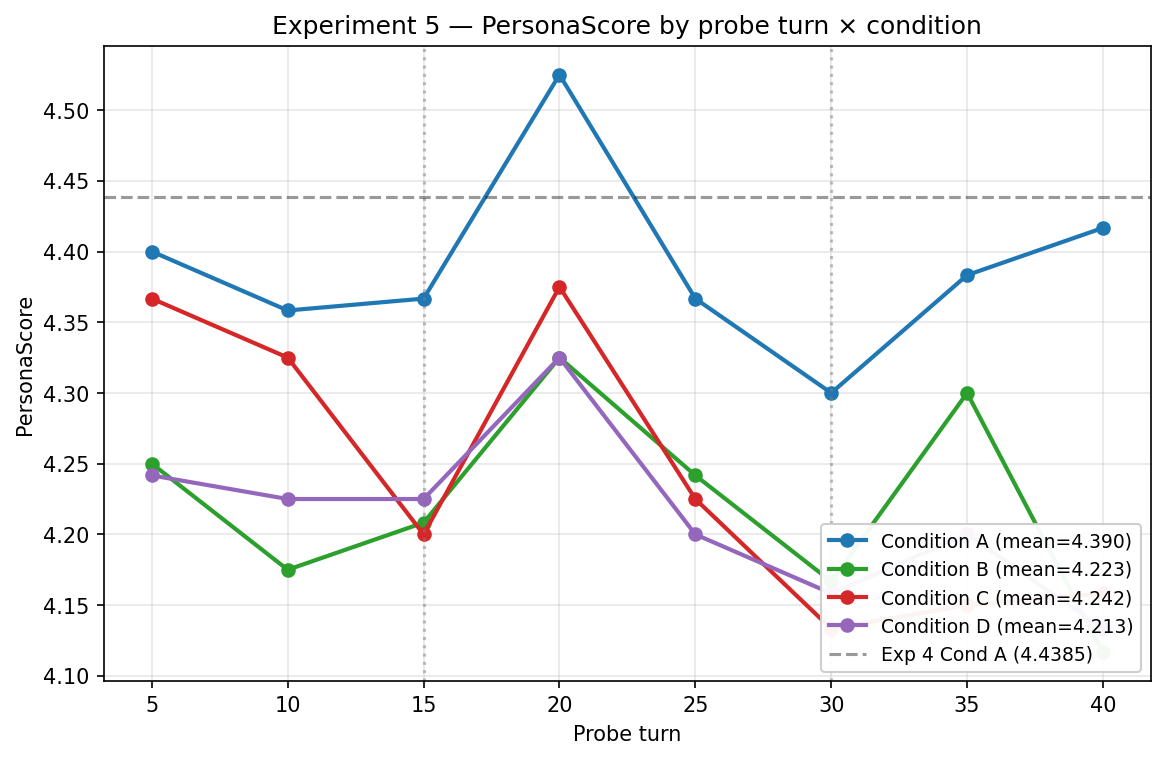

--- exp5_dimension_bars_psychotherapy.png ---


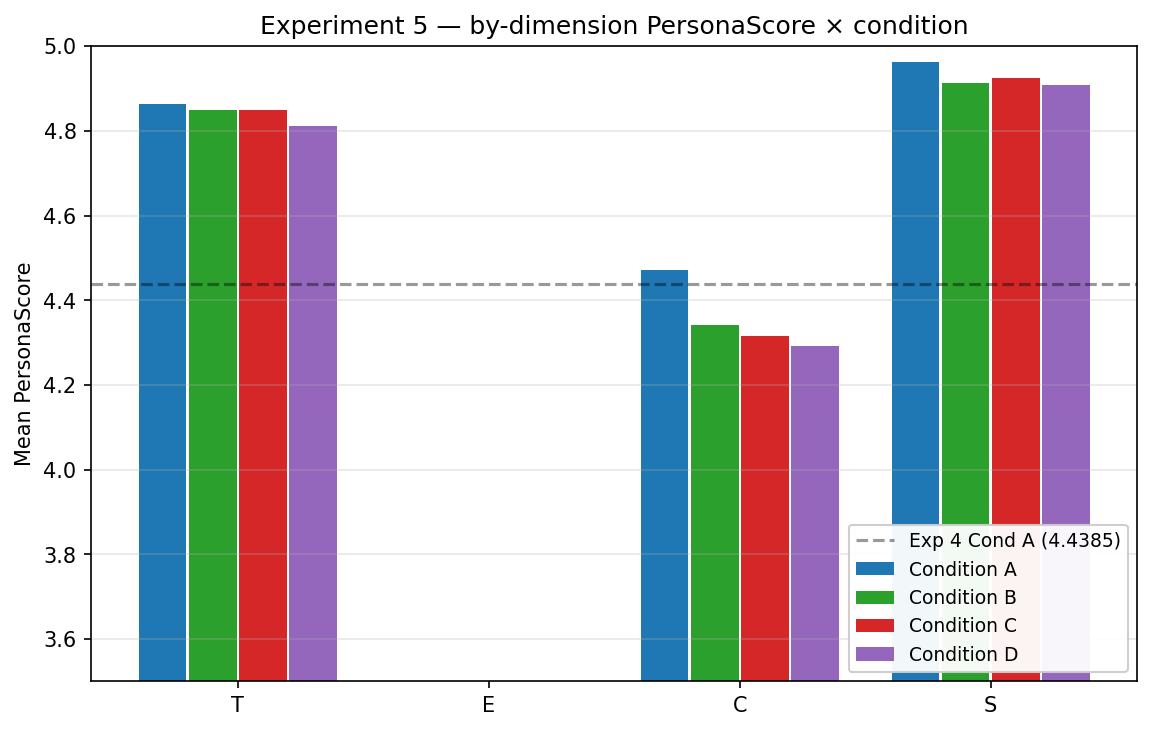

--- exp5_effect_size_ladder.png ---


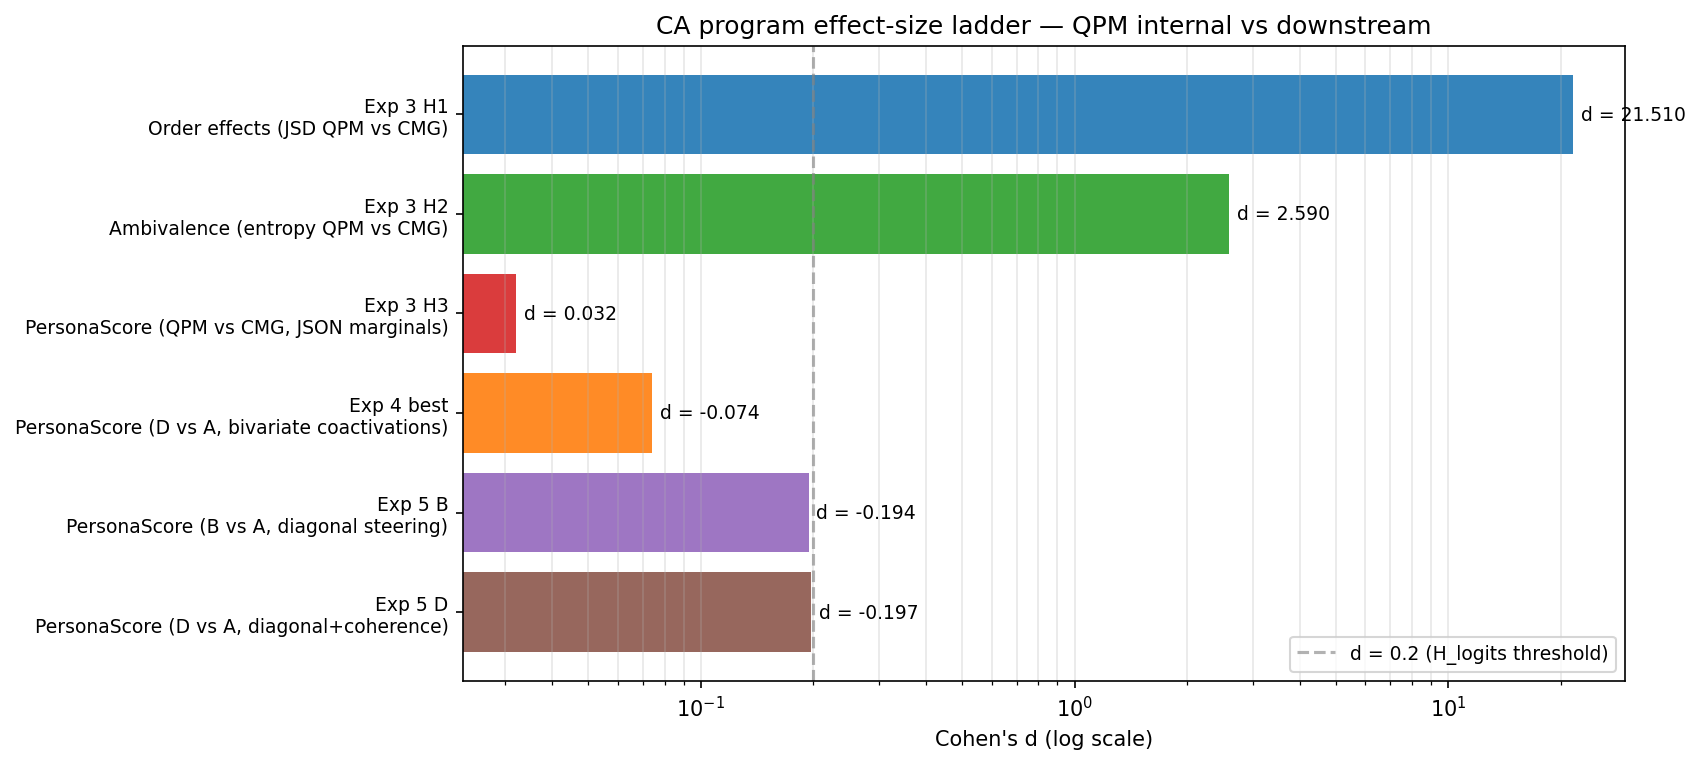

--- exp5_vector_norms.png ---


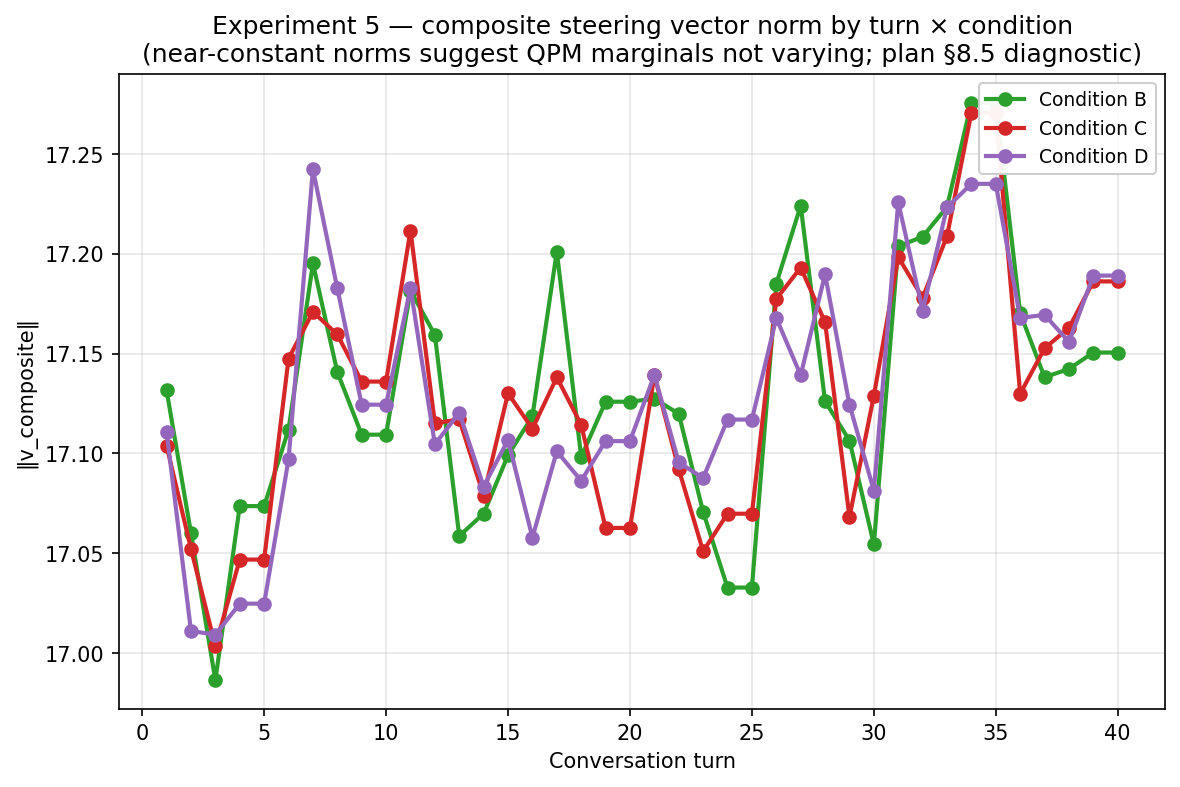

In [9]:
from IPython.display import Image, display
from pathlib import Path

for name in ('exp5_turn_series_psychotherapy.png',
             'exp5_dimension_bars_psychotherapy.png',
             'exp5_effect_size_ladder.png',
             'exp5_vector_norms.png'):
    path = Path(PROJECT_DIR) / 'results' / name
    if path.exists():
        print(f'--- {name} ---')
        display(Image(str(path)))
    else:
        print(f'  (missing: {name})')

---

## Recovery After Disconnect

1. Re-run **Cell 1** (mount Drive, set API key)
2. Re-run **Cell 2** (install core deps) — smoke-test imports
3. Re-run **Cell 3** (GPU + adapter check, install GPU deps)
4. **Phase 0 is resumable:**
   - If `phase0_activations/activations.npz` exists: Cell 4b skips forward passes and loads from cache.
   - If `steering_config.json` exists: re-run Cell 4f to verify the locked config, then skip to Cell 5.
   - If Phase 0 did not complete: re-run Cells 4a → 4f in order.
5. Re-run only the condition cells that did **not** finish — each is resumable per (script, condition).
6. Once all four conditions complete, re-run **Cell 9** (analysis) — idempotent.

### Useful flags

```
python3 experiment_runner.py --condition B --scripts 1-10
python3 experiment_runner.py --condition D --scripts 81-88
python3 experiment_runner.py --reliability
python3 analyse_results.py --conditions A,B
```

### If the continuity check fails

If Condition A mean drifts > ±0.05 from Exp 4 Condition A (4.4385), **stop** — something
in the SLM stack, prompt template, or judge state differs. Compare against
`CA_Experiment_4/results/analysis_data.json` to localise the drift.

### If Phase 0 qualitative validation fails (< 8/11 traits)

1. Check that `phase0_activations/activations.npz` was computed with the correct input format.
2. Delete `phase0_activations/activations.npz` and re-run Cell 4b with a larger contrastive
   corpus (increase `n` in Cell 4a from 50 to 100).
3. If α_max < 2.0 in Cell 4d, see plan §8.4.